In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sqlalchemy import create_engine

In [5]:
username = "root"
password = "1779"      
host = "localhost"
database = "olist_ecommerce_db"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}/{database}"
)

print("✅ Database Connected Successfully!")

✅ Database Connected Successfully!


In [6]:
customers = pd.read_sql("SELECT * FROM customers", engine)

orders = pd.read_sql("SELECT * FROM orders", engine)

payments = pd.read_sql("SELECT * FROM payments", engine)

order_items = pd.read_sql("SELECT * FROM order_items", engine)

products = pd.read_sql("SELECT * FROM products", engine)

reviews = pd.read_sql("SELECT * FROM order_reviews", engine)

sellers = pd.read_sql("SELECT * FROM sellers", engine)

category = pd.read_sql("SELECT * FROM category_translation", engine)

print("✅ All Tables Loaded Successfully!")

✅ All Tables Loaded Successfully!


In [7]:
master_df = orders.merge(customers, on="customer_id", how="left")

master_df = master_df.merge(payments, on="order_id", how="left")

master_df = master_df.merge(reviews, on="order_id", how="left")

master_df = master_df.merge(order_items, on="order_id", how="left")

master_df = master_df.merge(products, on="product_id", how="left")

master_df = master_df.merge(category, on="product_category_name", how="left")

master_df = master_df.merge(sellers, on="seller_id", how="left")

print(master_df.shape)

(119143, 40)


In [8]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    master_df[col] = pd.to_datetime(master_df[col])

In [9]:
master_df["delivery_days"] = (
    master_df["order_delivered_customer_date"]
    -
    master_df["order_purchase_timestamp"]
).dt.days

In [10]:
master_df["order_month"] = (
    master_df["order_purchase_timestamp"]
    .dt.month_name()
)

In [11]:
master_df["order_year"] = (
    master_df["order_purchase_timestamp"]
    .dt.year
)

In [12]:
master_df["purchase_hour"] = (
    master_df["order_purchase_timestamp"]
    .dt.hour
)

In [13]:
master_df["is_late_delivery"] = (
    master_df["order_delivered_customer_date"]
    >
    master_df["order_estimated_delivery_date"]
)

In [14]:
master_df["order_value_bucket"] = pd.cut(
    master_df["payment_value"],
    bins=[0,100,500,1000,100000],
    labels=["Low","Medium","High","Premium"]
)

In [15]:
master_df["freight_percentage"] = (
    master_df["freight_value"] /
    master_df["payment_value"]
) * 100

In [16]:
master_df["review_category"] = np.where(
    master_df["review_score"] >= 4,
    "Positive",
    np.where(
        master_df["review_score"] == 3,
        "Neutral",
        "Negative"
    )
)


In [17]:
master_df.shape

(119143, 48)

In [ ]:
# Revenue by State
# Top Product Categories
# Payment Method Analysis	
# Monthly Revenue Trend
# Delivery Performance
# Review Analysis
# Purchase Hour Analysis
# Customer Segmentation
# Freight Cost Analysis
# Executive KPIs

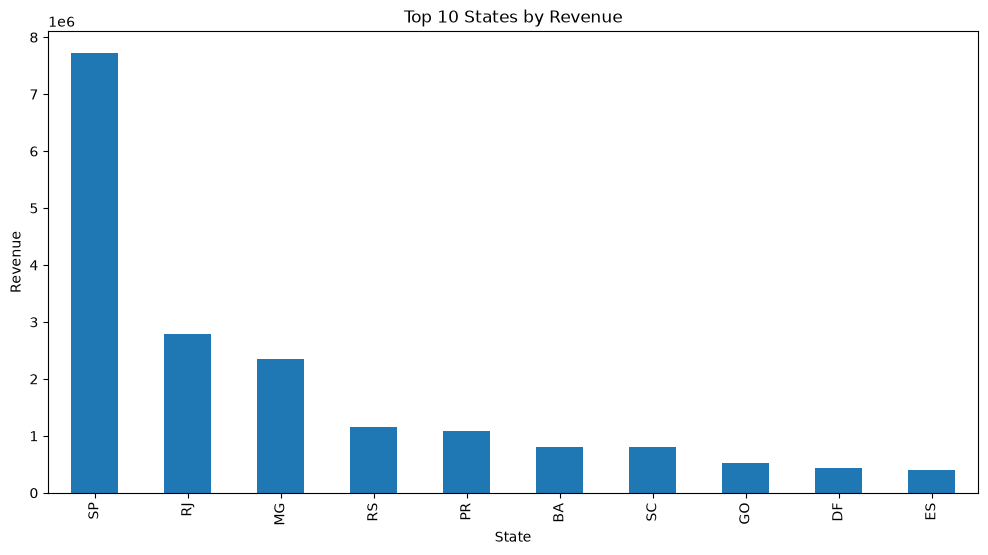

In [18]:
#Revenue by State
revenue_state = (
    master_df.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
revenue_state.head(10).plot(kind="bar")

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

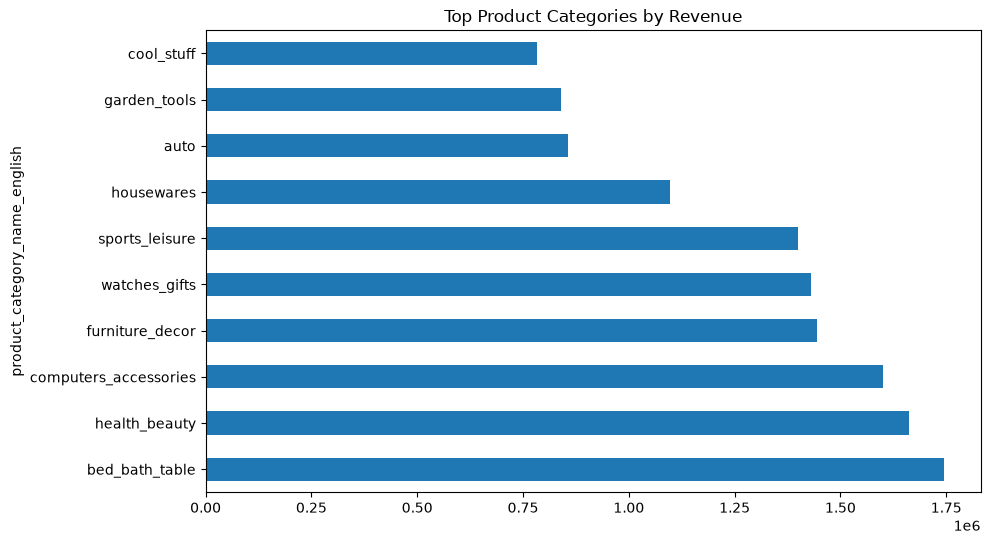

In [19]:
# Top Product Categories
category_revenue = (
    master_df.groupby("product_category_name_english")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
category_revenue.head(10).plot(kind="barh")

plt.title("Top Product Categories by Revenue")

plt.show()

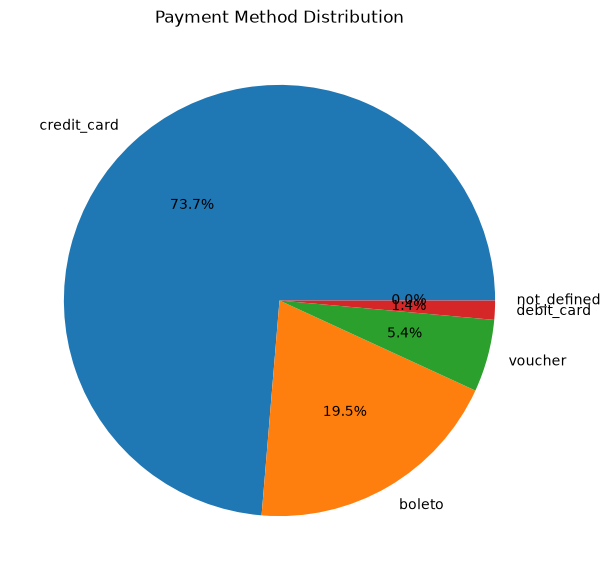

In [21]:
# Payment Method Analysis
payment = master_df["payment_type"].value_counts()

plt.figure(figsize=(7,7))
payment.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Payment Method Distribution")

plt.show()

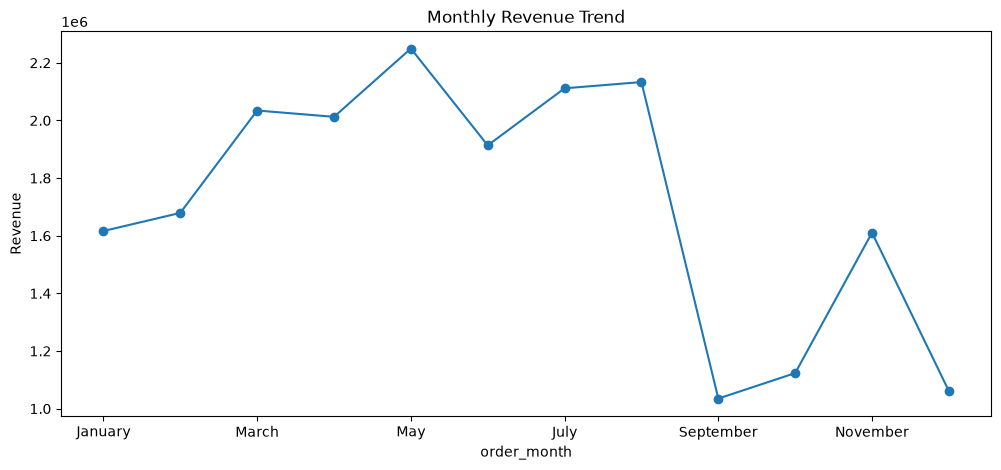

In [22]:
# Monthly Revenue Trend
monthly = (
    master_df.groupby("order_month")["payment_value"]
    .sum()
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = monthly.reindex(month_order)

plt.figure(figsize=(12,5))
monthly.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")

plt.show()

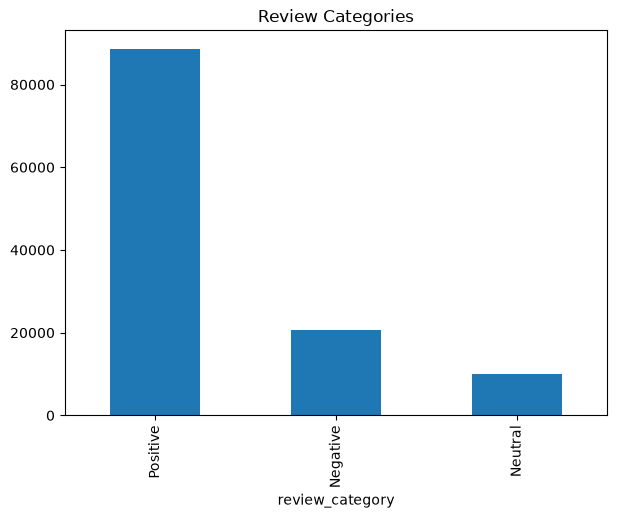

In [23]:
# Review Score Distribution
review = master_df["review_category"].value_counts()

plt.figure(figsize=(7,5))
review.plot(kind="bar")

plt.title("Review Categories")

plt.show()

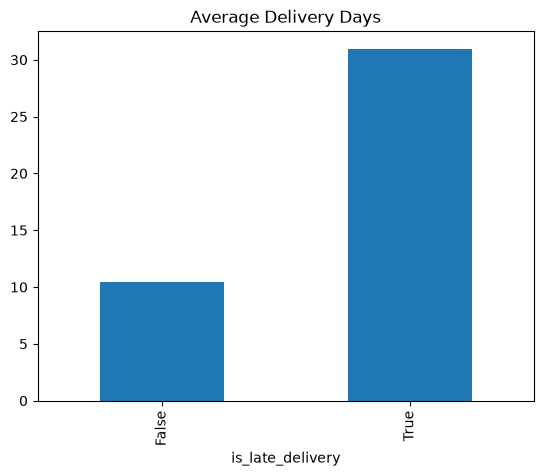

In [24]:
# Delivery Performance
delivery = (
    master_df.groupby("is_late_delivery")["delivery_days"]
    .mean()
)

delivery.plot(kind="bar")

plt.title("Average Delivery Days")

plt.show()

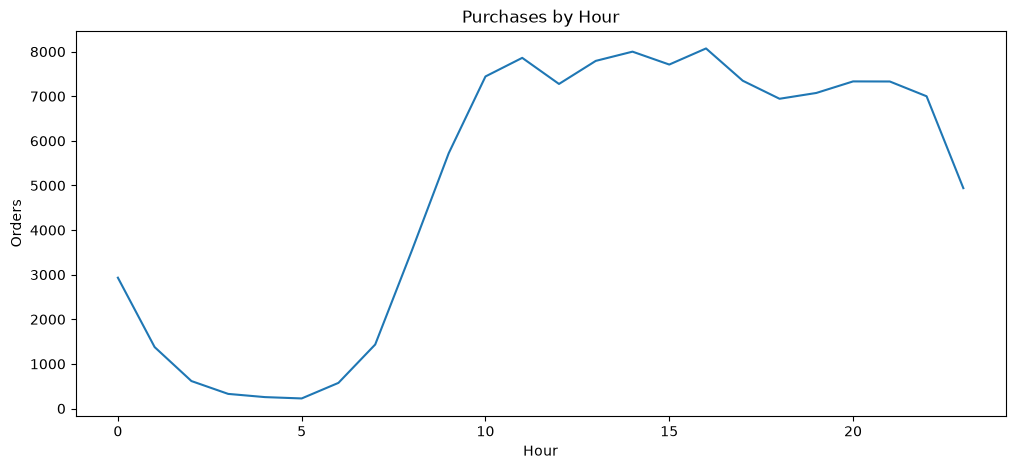

In [25]:
# Purchase Hour Analysis
hour = master_df["purchase_hour"].value_counts().sort_index()

plt.figure(figsize=(12,5))
hour.plot()

plt.title("Purchases by Hour")

plt.xlabel("Hour")

plt.ylabel("Orders")

plt.show()

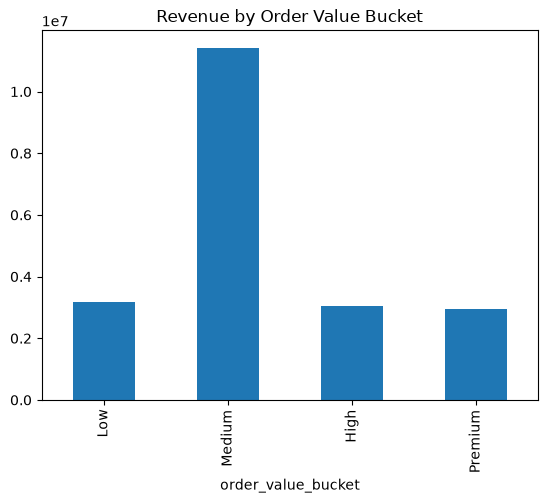

In [26]:
# Order Value Bucket
bucket = (
    master_df.groupby("order_value_bucket")["payment_value"]
    .sum()
)

bucket.plot(kind="bar")

plt.title("Revenue by Order Value Bucket")

plt.show()

C:\Users\sujit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\sujit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


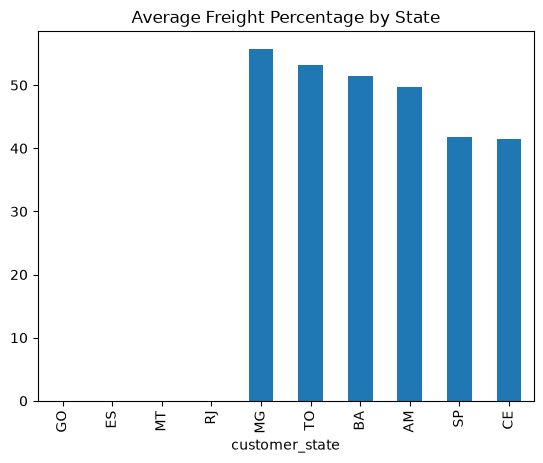

In [27]:
# Freight Percentage
state_freight = (
    master_df.groupby("customer_state")["freight_percentage"]
    .mean()
    .sort_values(ascending=False)
)

state_freight.head(10).plot(kind="bar")

plt.title("Average Freight Percentage by State")

plt.show()

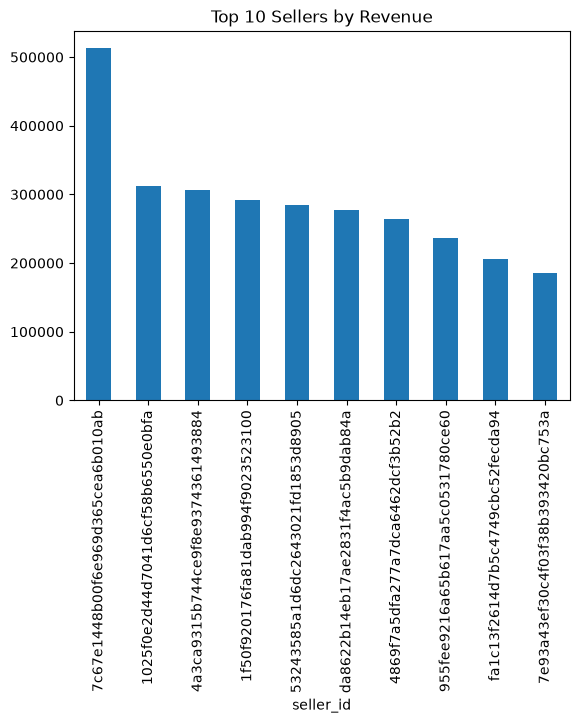

In [28]:
# Top 10 Sellers
seller = (
    master_df.groupby("seller_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

seller.head(10).plot(kind="bar")

plt.title("Top 10 Sellers by Revenue")

plt.show()